In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import great_tables
from great_tables import GT, md, html
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.stats.api as sms
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from matplotlib import pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.factorplots import interaction_plot
from scipy.stats import levene
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import pearsonr
from config import *

In [2]:
data =  pd.read_excel(r"Results_isofys\data_for_R.xlsx") #work with the most updated and cleaned database
data = data.drop(columns = ["Unnamed: 0"])
data['Plot'] = data["Plot"].astype("category")
data['TreeID'] = data["TreeID"].astype("category")
#data['code'] = data["code"].astype("category")
data["Sub"] = data["Sub"].astype("category")
data["name"] = data["name"].astype("category")
data["Site"] = data["Site"].astype("category")
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Plot                        182 non-null    category      
 1   TreeID                      182 non-null    category      
 2   Sub                         182 non-null    category      
 3   name                        182 non-null    category      
 4   genus                       87 non-null     object        
 5   specie                      182 non-null    object        
 6   Site                        182 non-null    category      
 7   [C_b]                       182 non-null    float64       
 8   bulk_δ13C (‰ v.s.V-PDB)     182 non-null    float64       
 9   [N]                         181 non-null    float64       
 10  δ15N (‰ v.s.AIR)            182 non-null    float64       
 11  [O]                         182 non-null    float64       

In [3]:
table = data.groupby(["elevation_m",'name', 'Sub']).size().unstack(fill_value=0)
table = table[table["C"]!=0].reset_index()
# Optional: rename columns for clarity
table.columns.name = None
table.rename(columns={"C":"C", "P":"P", "NP":"NxP"}, inplace=True)
table



,elevation_m,name,C,N,NxP,P
0,1000,Clarisia racemosa,3,1,4,4
1,1000,Pouteria torta,11,10,7,8
2,2000,Alchornea lojaensis,12,10,8,15
3,2000,Myrcia sp nov,15,10,13,12
4,3000,Hedyosmun purpurascens,5,6,3,7
5,3000,Weinmania loxensis,5,5,2,6


In [4]:
table = data.groupby(["elevation_m",'name', 'Sub',"Bloque"]).size().unstack(fill_value=0)
table.to_excel("Bloque.xlsx")


In [5]:
iWUE = "iWUE (μmol/mol)"

def table_summary(df):
    """This code do the last cleaning up of my database"""
    main = ["name","Sub","elevation_m",named13C_cellulose,iWUE,SLA,"LCC","LNC","LPC","N:P","C:N"]
    secondary = ["name","Sub","elevation_m",named13C_cellulose,iWUE,SLA,"C_area","N_area","P_area"]
    data = df[main]
   # columskeep = []
    description = data.groupby(["elevation_m",'name', 'Sub']).agg(["mean","std"]).round(2).dropna(how="all")
   # Get the name of the first numeric column
    first_numeric = data.select_dtypes("number").columns[0]
   # Keep only one 'count' column + all mean/std columns
    description = pd.concat([
    #description.loc[:, (first_numeric, "count")],
    description.loc[:, pd.IndexSlice[:, ["mean", "std"]]]
       ], axis=1)
    # Sort by elevation
    
    #description = description.sort_values("elevation_m", ascending=True)
    description.to_excel("Summary.xlsx")
    print("Summary created and exported to Excel file")
    return description

table_summary(data) #HELP Define que necesitamos

Summary created and exported to Excel file


δ13C (‰ v.s.V-PDB)        \
                                                      mean   std   
elevation_m name                    Sub                            
1000        Clarisia  racemosa      C               -30.63  0.42   
                                    N               -31.80   NaN   
                                    NP              -30.88  0.36   
                                    P               -29.84  1.24   
            Pouteria torta          C               -31.55  0.76   
                                    N               -31.27  0.87   
                                    NP              -31.74  1.35   
                                    P               -31.27  0.93   
2000        Alchornea lojaensis     C               -26.51  0.89   
                                    N               -26.57  1.13   
                                    NP              -26.77  1.45   
                                    P               -27.06  1.51   
            Myrcia sp nov           C               -27.79  1.15   
                                    N               -27.24  0.92   
                                    NP              -27.27  1.00   
                                    P               -27.34  0.66   
3000        Hedyosmun  purpurascens C               -26.81  1.44   
                                    N               -26.35  2.06   
                                    NP              -24.85  1.27   
                                    P               -27.29  1.59   
            Weinmania  loxensis     C               -27.70  0.27   
                                    N               -28.06  0.90   
                                    NP              -29.03  0.79   
                                    P               -28.38  1.13   

                                        iWUE (μmol/mol)         \
                                                   mean    std   
elevation_m name                    Sub                          
1000        Clarisia  racemosa      C             36.98   5.19   
                                    N             22.59    NaN   
                                    NP            33.97   4.43   
                                    P             46.63  15.20   
            Pouteria torta          C             25.62   9.34   
                                    N             40.17  22.44   
                                    NP            23.36  16.58   
                                    P             29.13  11.48   
2000        Alchornea lojaensis     C             87.61  10.75   
                                    N             86.90  13.72   
                                    NP            84.43  17.61   
                                    P             81.01  18.29   
            Myrcia sp nov           C             72.02  13.97   
                                    N             78.70  11.13   
                                    NP            78.33  12.19   
                                    P             77.63   8.05   
3000        Hedyosmun  purpurascens C             83.75  17.60   
                                    N             89.25  25.08   
                                    NP           107.56  15.36   
                                    P             77.86  19.36   
            Weinmania  loxensis     C             72.87   3.29   
                                    N             68.51  10.95   
                                    NP            56.60   9.70   
                                    P             64.54  13.80   

                                        Specific leaf area (cm²/g)         \
                                                              mean    std   
elevation_m name                    Sub                                     
1000        Clarisia  racemosa      C                        92.05  10.83   
                                    N                       112.06    NaN   
                                   

# Relaciones con los nutrientes

<Axes: xlabel='Specific leaf area (cm²/g)', ylabel='iWUE (μmol/mol)'>

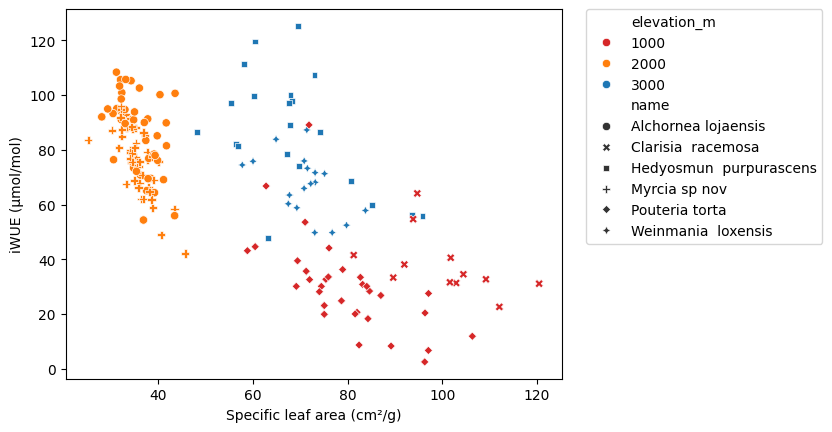

In [6]:
def  scatter_elev_shape(df,trait,var):
  
 color_map = {
    1000: "tab:red",
    2000: "tab:orange",
    3000: "tab:blue"
    }

 colors = df["elevation_m"].map(color_map)
 figsize=(6.5,6.5)
 fig = sns.scatterplot(data= df, x=trait, y=var, hue="elevation_m",palette= color_map,style="name",          # forma (shape)
    markers=True  )  #legend=True)

 plt.legend(
    bbox_to_anchor=(1.05, 1),  # mueve la leyenda fuera
    loc='upper left',
    borderaxespad=0.
  )
 return fig
#set_title('Total')
#set_xlabel(trait)

scatter_elev_shape(data,SLA,iWUE)
#scatter_elev_shape(data,LNC,iWUE)
#scatter_elev_shape(data,LPC,iWUE)

<Axes: xlabel='LNC', ylabel='iWUE (μmol/mol)'>

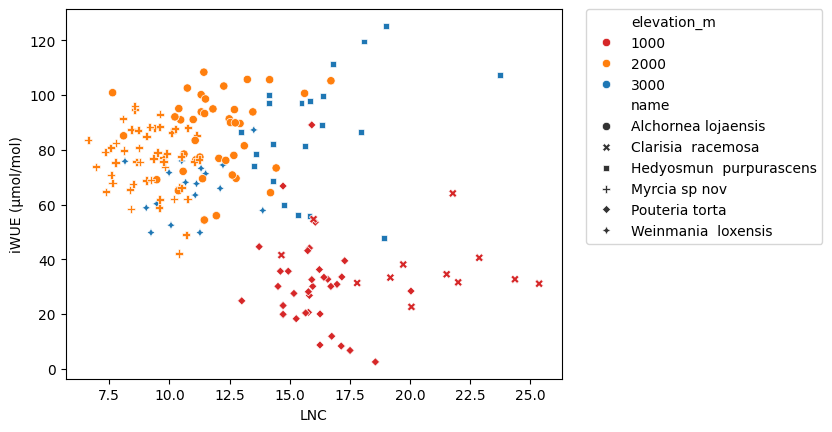

In [7]:
scatter_elev_shape(data,LNC,iWUE)

<Axes: xlabel='LNC', ylabel='δ18O in ‰ vs DeltaSMOW'>

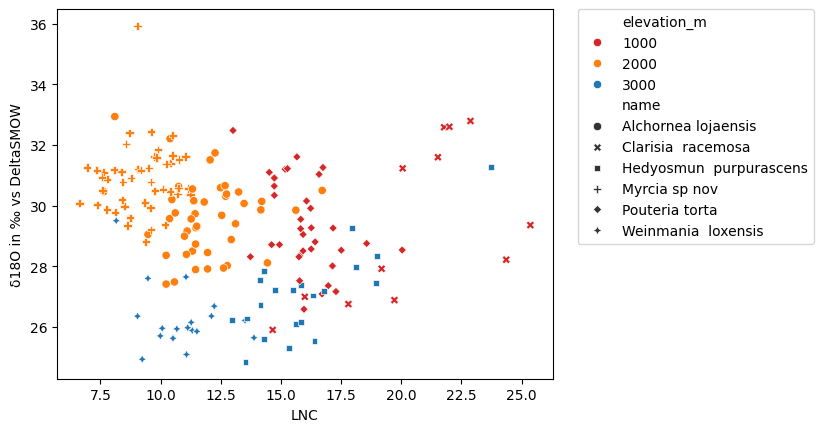

In [8]:
scatter_elev_shape(data,LNC,name18O)

<Axes: xlabel='N:P', ylabel='iWUE (μmol/mol)'>

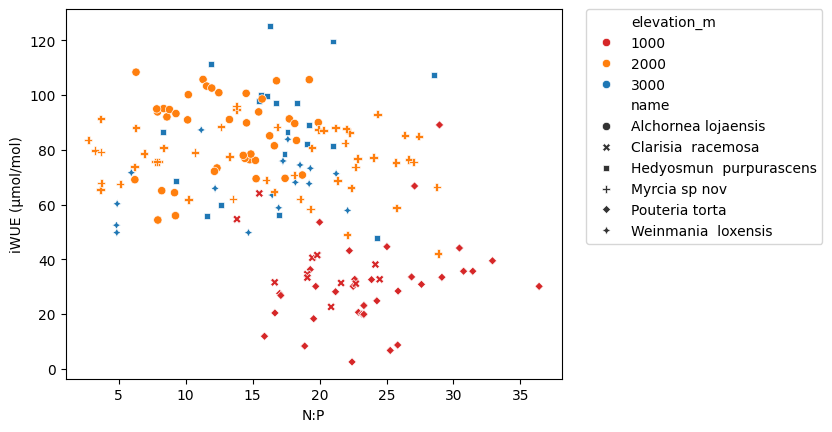

In [9]:
#scatter_elev_shape(data,"elevation_m",NP_ratio)
scatter_elev_shape(data,NP_ratio,iWUE)


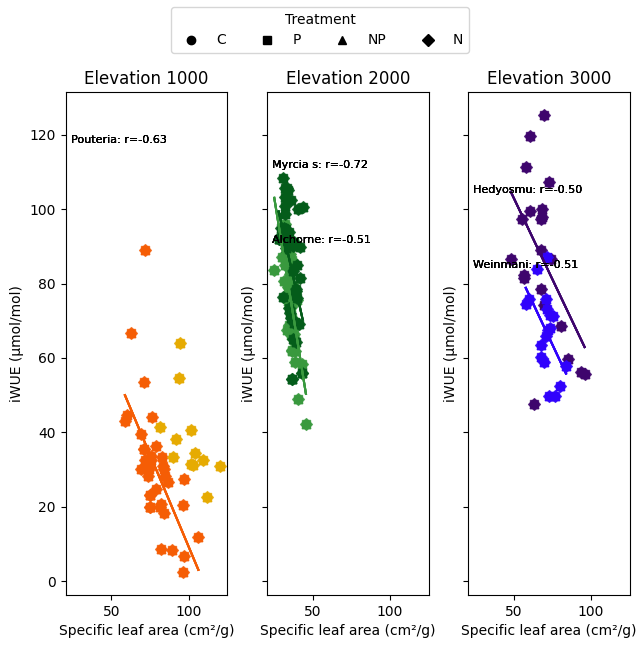

In [10]:
def relation_nutrients_iWUE_1x3(df, x, y):

    subs = ['C', 'P', 'NP', 'N']

    species_order = [
        "Pouteria torta",
        "Myrcia sp nov",
        "Hedyosmun  purpurascens",
        "Clarisia  racemosa",
        "Alchornea lojaensis",
        "Weinmania  loxensis"
    ]

    palette_species = {
        "Pouteria torta": "#f55d05",
        "Clarisia  racemosa": "#e6ab02",
        "Myrcia sp nov": "#39993e",
        "Alchornea lojaensis": "#045C1A",
        "Weinmania  loxensis": "#3002fc",
        "Hedyosmun  purpurascens": "#3e056d",
    }

    markers = ['o', 's', '^', 'D']
    marker_map = dict(zip(subs, markers))

    elevations = sorted(df["elevation_m"].dropna().unique())

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(elevations),
        figsize=(6.5,6.5),
        sharex=True,
        sharey=True
    )

    for i, elev in enumerate(elevations):

        ax = axes[i]
        df_elev = df[df["elevation_m"] == elev]

        for sp in species_order:

            for sub in subs:

                data_sub = df_elev[(df_elev['name'] == sp)][[x,y]].dropna()
                if len(data_sub) < 2:
                    continue

                xvals = data_sub[x]
                yvals = data_sub[y]

                r, p = pearsonr(xvals, yvals)

                # Only show significant correlations

                ax.scatter(
                        xvals,
                        yvals,
                        color=palette_species[sp],
                        marker=marker_map[sub],
                        alpha=0.8
                    )

                    
                if p < 0.05:

                    ax.text(
                        0.03,
                        0.9 - 0.05*(species_order.index(sp)),
                        f"{sp[:8]}: r={r:.2f}",
                        transform=ax.transAxes,
                        fontsize=8
                    )

                    # regression line
                    m, b = np.polyfit(xvals, yvals, 1)
                    xs = np.array([xvals.min(), xvals.max()])
                    ys = m * xs + b

                    ax.plot(
                        xs,
                        ys,
                        color=palette_species[sp],
                        linewidth=1.5
                    )

        ax.set_title(f"Elevation {elev}")
        ax.set_xlabel(x)
        ax.set_ylabel(y)

    # legend for treatments (shapes)
    shape_handles = [
        plt.Line2D([0],[0],
                   marker=marker_map[sub],
                   linestyle="",
                   color="black",
                   label=sub)
        for sub in subs
    ]

    fig.legend(handles=shape_handles,
               loc="upper center",
               ncol=len(subs),
               title="Treatment")

    plt.tight_layout(rect=[0,0,1,0.92])
    plt.show()


relation_nutrients_iWUE_1x3(data, SLA, iWUE)

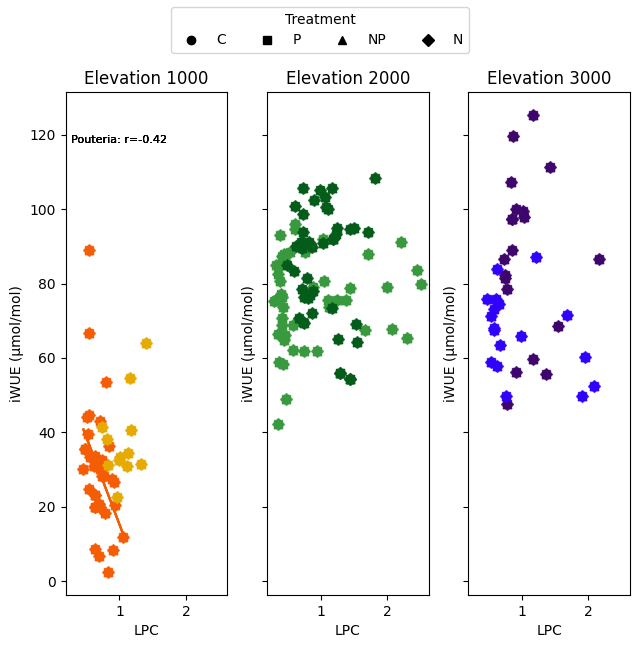

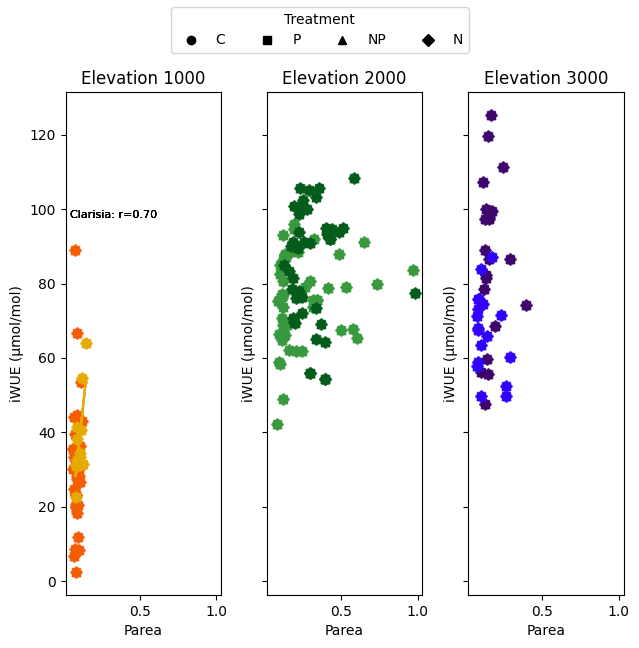

In [11]:
data["Parea"] = data["P (mg/g)"]*(1/data[SLA])*(10)
data["N:P"] = data["P (mg/g)"]/(data["[N]"]*100)#HELP: Revisar unidades

relation_nutrients_iWUE_1x3(data, "LPC", iWUE)
relation_nutrients_iWUE_1x3(data, "Parea", iWUE)

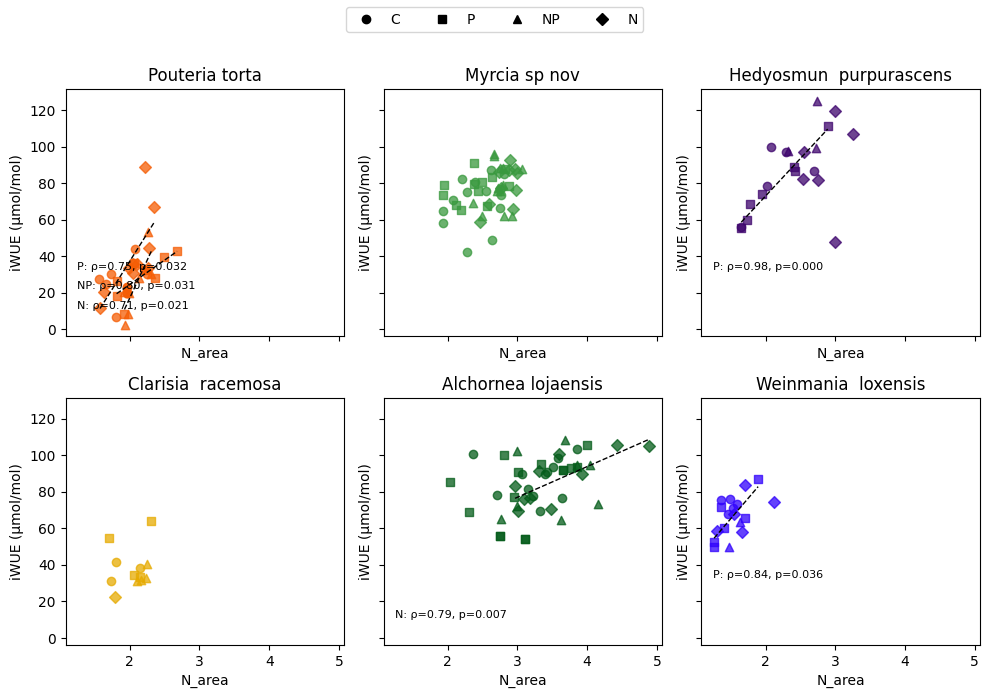

In [12]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import itertools


def relation_nutrients_iWUE_2x3(df, x, y):
    subs = ['C', 'P', 'NP', 'N']

    # Species order (explicit)
    species_order = [
        "Pouteria torta",
        "Myrcia sp nov",
        "Hedyosmun  purpurascens",
        "Clarisia  racemosa",
        "Alchornea lojaensis",
        "Weinmania  loxensis"
    ]

    palette_species = {
    "Pouteria torta": "#f55d05",
    "Clarisia  racemosa": "#e6ab02",
    "Myrcia sp nov": "#39993e",
    "Alchornea lojaensis": "#045C1A",
    "Weinmania  loxensis": "#3002fc",
    "Hedyosmun  purpurascens": "#3e056d",
     }

    # Color per Sub
    palette_Sub = {
        "C": "#A3A3A3",
        "N": "#70b7f5",
        "P": "#F7AC58FF",
        "NP": "#f080ca"
         }

    # Marker per treatment
    markers = ['o', 's', '^', 'D']
    marker_map = dict(zip(subs, markers))

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(10, 7),
        sharex=True,
        sharey=True
    )

    axes = axes.flatten()

    for i, sp in enumerate(species_order):
        ax = axes[i]

        for sub in subs:
            data_sub = df[(df['name'] == sp) & (df['Sub'] == sub)]
            data_sub = data_sub[[x, y]].dropna()

            if data_sub.empty:
                continue

            ax.scatter(
                data_sub[x],
                data_sub[y],
                alpha=0.75,
                color=palette_species[sp],
                marker=marker_map[sub],
                label=sub
            )
     # Linear trend line per treatment
            

            # Correlation per treatment (optional)
            if len(data_sub) > 1:
                r, p = pearsonr(data_sub[x], data_sub[y])
                if p < 0.05:

                 ax.text(
                    0.04, 0.35 - 0.08 * subs.index(sub),
                    f"{sub}: ρ={r:.2f}, p={p:.3f}",
                    transform=ax.transAxes,
                    fontsize=8,
                    color="black"
                 )
                 if len(data_sub) > 1:
                 # Fit line: y = m*x + b
                  m, b = np.polyfit(data_sub[x], data_sub[y], 1)
                  x_vals = np.array([data_sub[x].min(), data_sub[x].max()])
                  y_vals = m * x_vals + b
                  ax.plot(x_vals, y_vals, color="black", linestyle='--', linewidth=1)

        ax.set_title(sp, fontsize=12)
        ax.set_xlabel(x)
        ax.set_ylabel(y)

    # Single legend for treatments (shapes)
    handles = [
        plt.Line2D(
            [0], [0],
            marker=marker_map[sub],
            color='black',
            linestyle='',
            label=sub
        )
        for sub in subs
    ]

    fig.legend(
        handles=handles,
        labels=subs,
        loc="upper center",
        ncol=len(subs),
        frameon=True
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

relation_nutrients_iWUE_2x3(data, Narea, iWUE)

# GRAFICOS IMPORTANTES

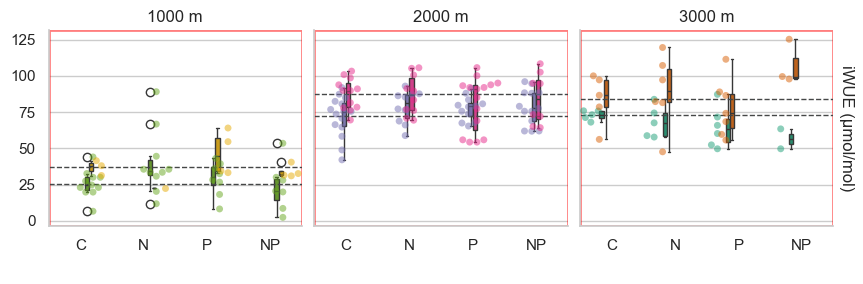

In [13]:

import boxplot_elev
%run boxplot_elev.py
 
create_boxplots_elev(iWUE,data,ax=None)

In [14]:
import create_boxplots_control
%run create_boxplots_control.py

C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\categorical.py:3398: UserWarning: 10.0% of the points cannot be placed; you may want to decre

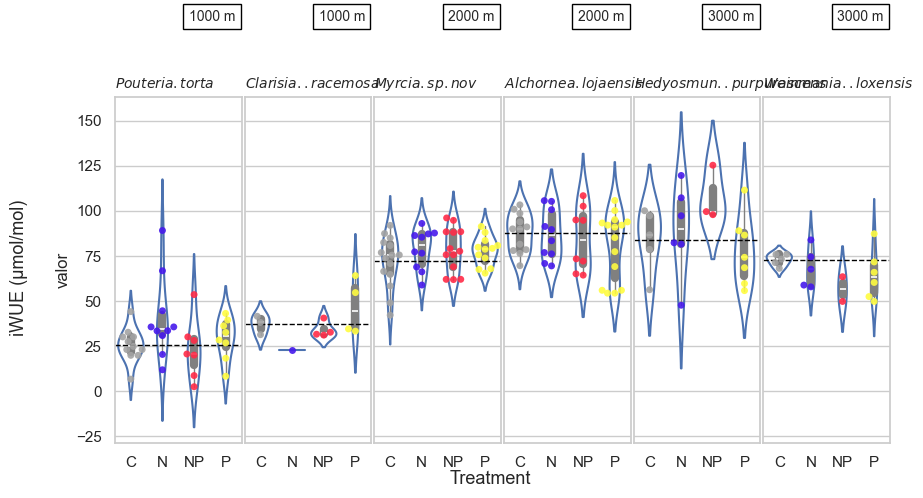

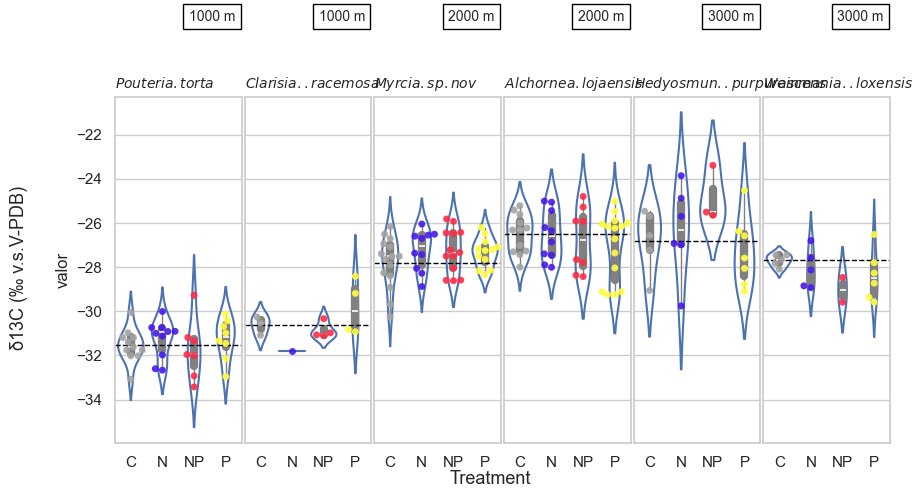

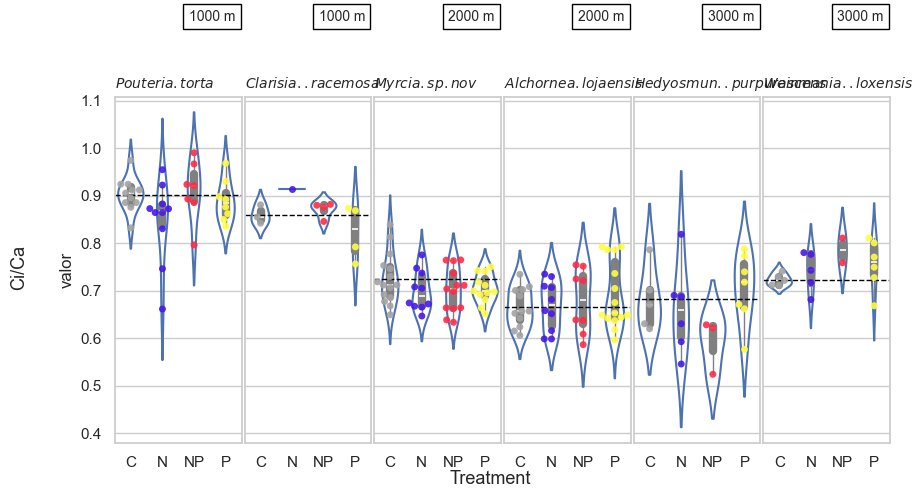

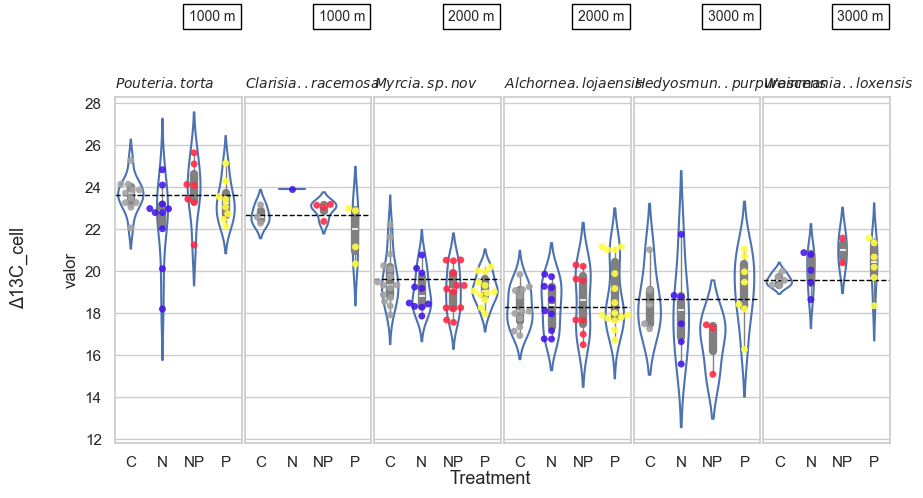

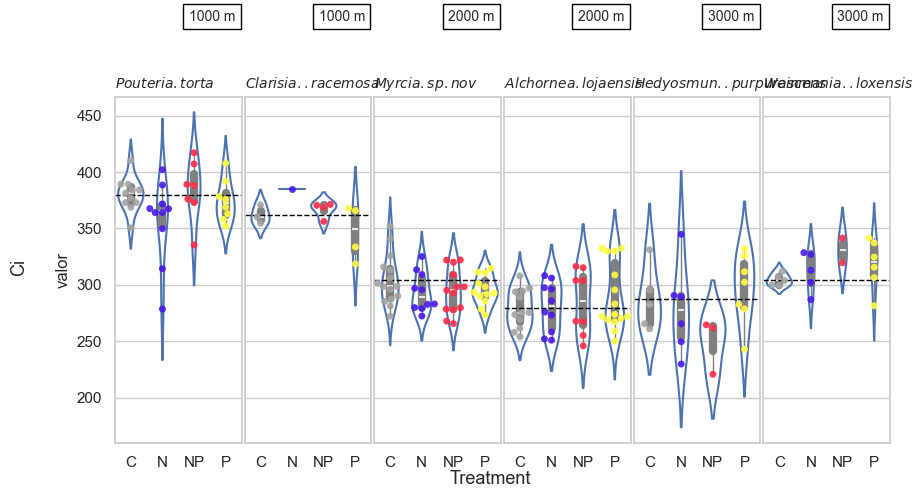

In [15]:
variables_isotopos = [iWUE, named13C_cellulose,"Ci/Ca","Δ13C_cell","Ci"] 

isotopos = variables_isotopos
for variable in isotopos: 
 create_boxplots_control(variable,data)

C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\categorical.py:3398: UserWarning: 11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\categorical.py:3398: UserWarning: 22.2% of the points cannot be placed; you may want to decrease the size of the markers or use strip

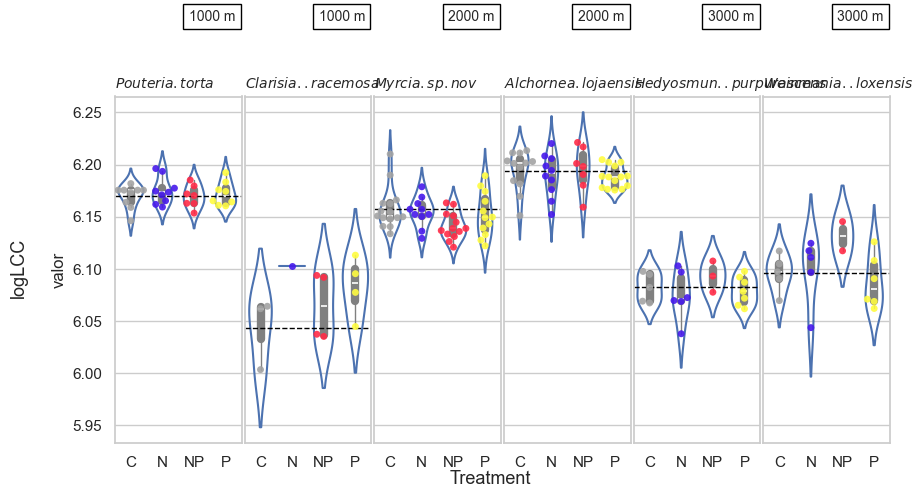

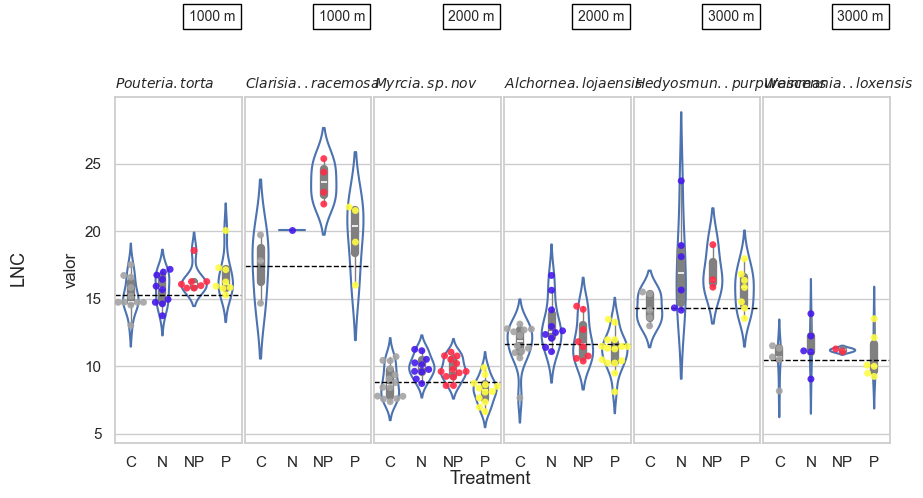

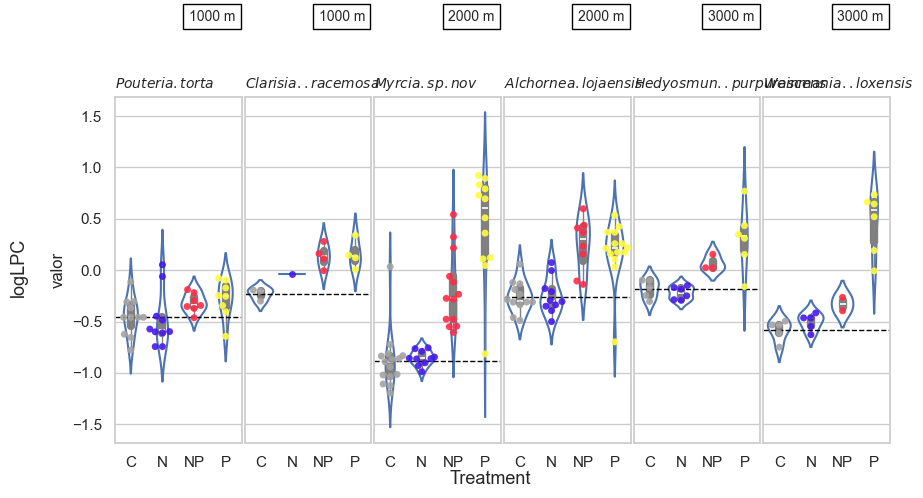

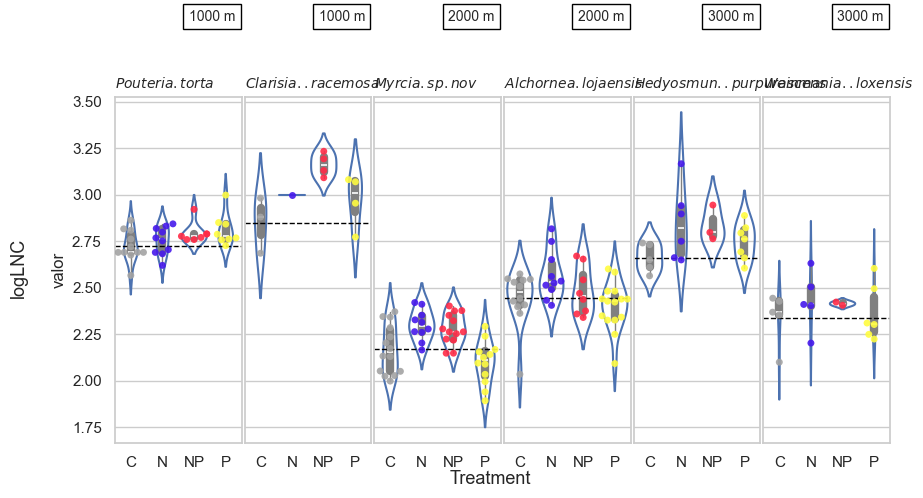

In [16]:
data["logLCC"] = np.log(data[LCC])
data["logLNC"] = np.log(data[LNC])
data["logLPC"] = np.log(data[LPC])

nutrientes_log = ["logLCC","LNC","logLPC","logLNC"] # Calculate natural logarithm on
for variable in nutrientes_log:

 create_boxplots_control(variable,data)

C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\categorical.py:3398: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\categorical.py:3398: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use strippl

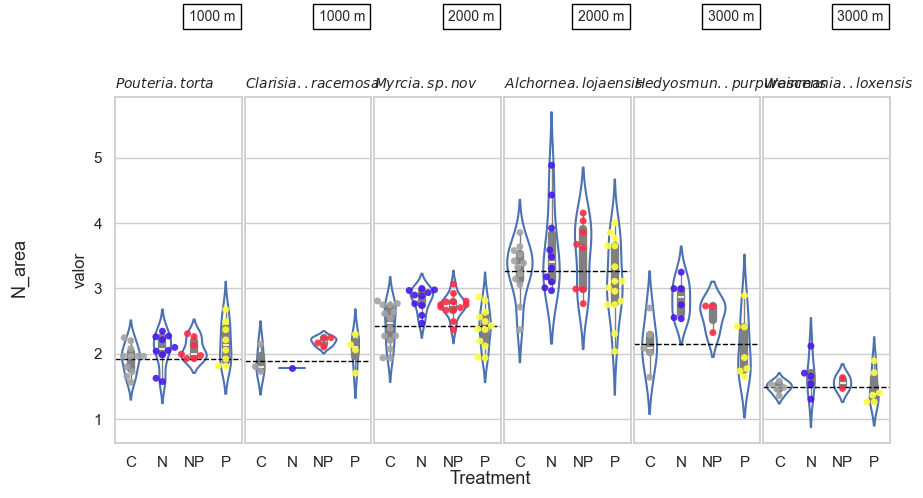

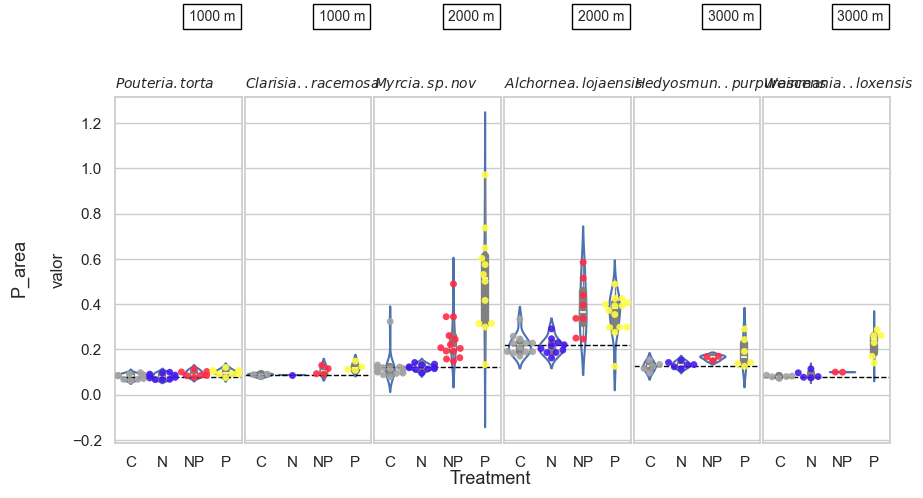

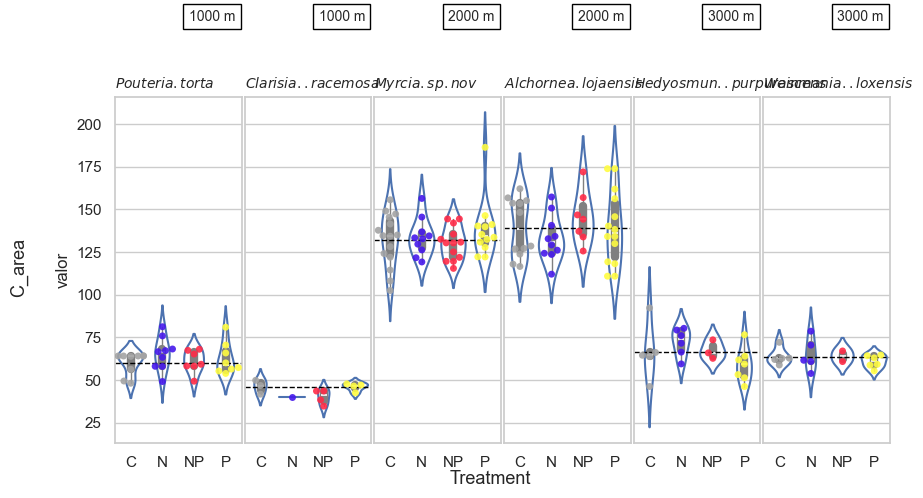

In [17]:
areas = ["N_area","P_area","C_area"] 
for variable in areas:

 create_boxplots_control(variable,data)

C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\categorical.py:3398: UserWarning: 36.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\selene.baez\Downloads\NUMEX_preliminar\create_boxplots_control.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\categorical.py:3398: UserWarning: 36.4% of the points cannot be placed; you may want to decrease the size of the markers or use strip

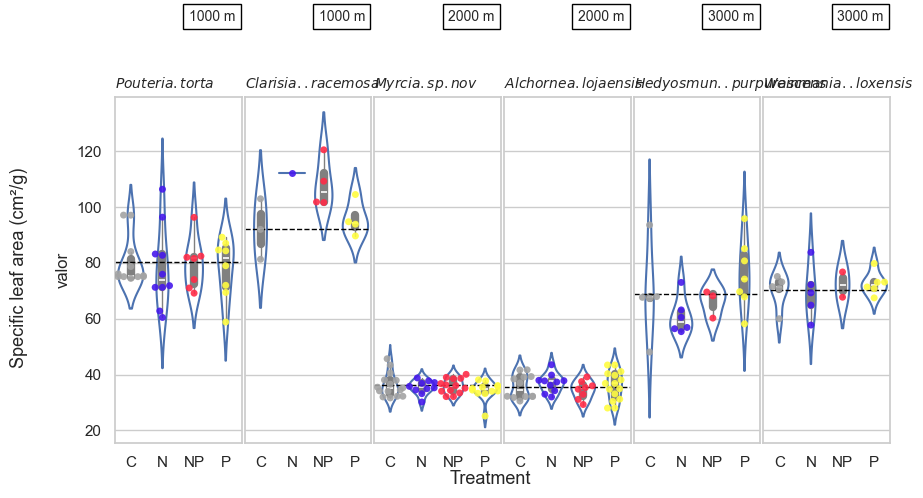

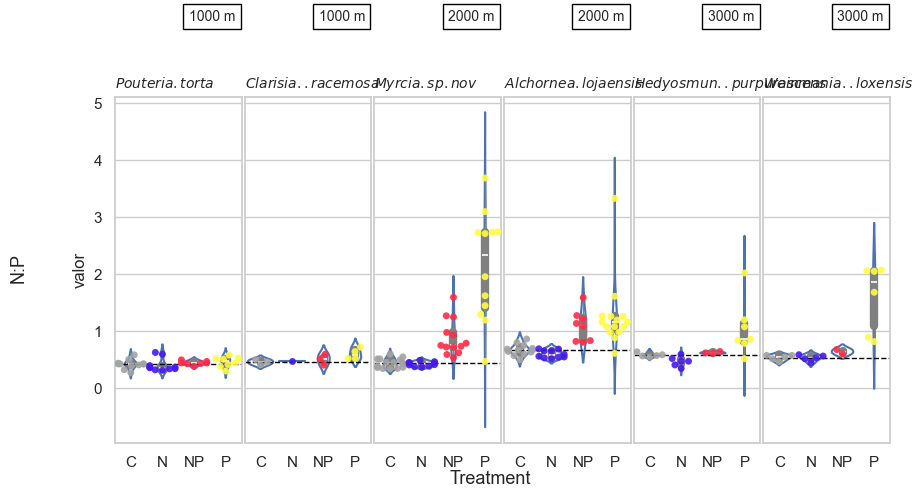

In [18]:
nutrientes = [SLA,NP_ratio] 
for variable in nutrientes:

 create_boxplots_control(variable,data)

In [19]:
# Comparaciones grupos Kruskall

In [20]:
%run kruskal_por_especie_y_tratamiento.py

kruskal_por_especie_y_tratamiento(data, variable=iWUE)



Procesando Especie: Weinmania  loxensis

Total muestras: 18
Comparacion entre tratamientos
C: n = 5
N: n = 5
P: n = 6
NP: n = 2
iWUE (μmol/mol)

TEST KRUSKALL
H = 4.526, p = 0.2100, df = 3

TEST ANOVA DE UNA VIA
F-statistic: 1.2964741281055632
P-value: 0.31450160565924384

Procesando Especie: Pouteria torta

Total muestras: 36
Comparacion entre tratamientos
NP: n = 7
P: n = 8
N: n = 10
C: n = 11
iWUE (μmol/mol)

TEST KRUSKALL
H = 6.000, p = 0.1116, df = 3

TEST ANOVA DE UNA VIA
F-statistic: 2.085761771302465
P-value: 0.12165273081003829

Procesando Especie: Hedyosmun  purpurascens

Total muestras: 21
Comparacion entre tratamientos
P: n = 7
NP: n = 3
C: n = 5
N: n = 6
iWUE (μmol/mol)

TEST KRUSKALL
H = 4.585, p = 0.2049, df = 3

TEST ANOVA DE UNA VIA
F-statistic: 1.542568489852132
P-value: 0.23985639528737393

Procesando Especie: Clarisia  racemosa

Total muestras: 12
Comparacion entre tratamientos
NP: n = 4
P: n = 4
N: n = 1
C: n = 3
iWUE (μmol/mol)

TEST KRUSKALL
H = 5.000, p = 0.171

[{'H': 4.5263085399449015, 'p': 0.20995559590402574, 'df': 3},
 {'H': 6.000131743819749, 'p': 0.11160381564747858, 'df': 3},
 {'H': 4.584702496983209, 'p': 0.20485831325967638, 'df': 3},
 {'H': 5.0, 'p': 0.1717971442967335, 'df': 3},
 {'H': 2.3372344788599126, 'p': 0.5054253215246822, 'df': 3},
 {'H': 0.6469579160077237, 'p': 0.8856031990005733, 'df': 3}]

# Relacion d13C y d18O

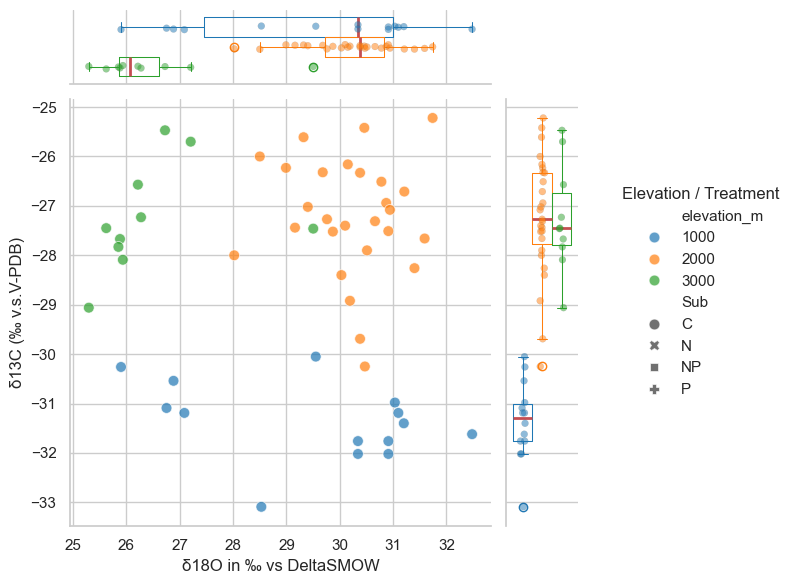

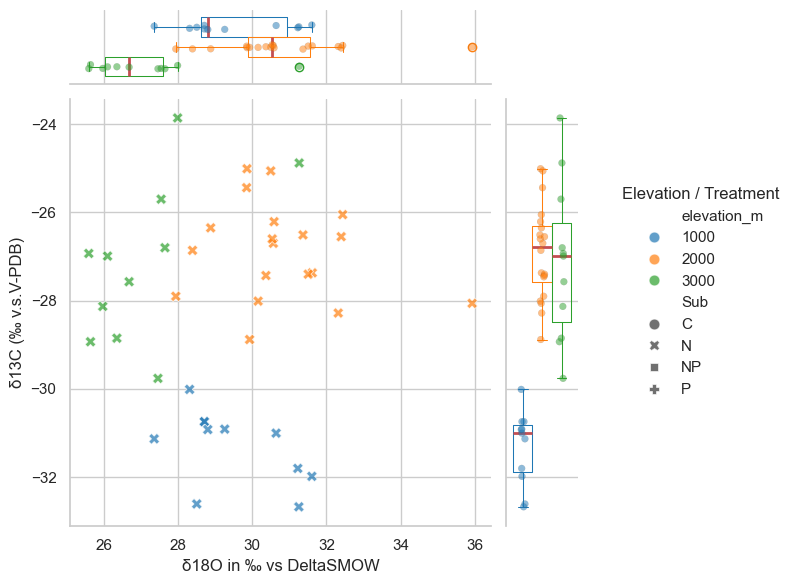

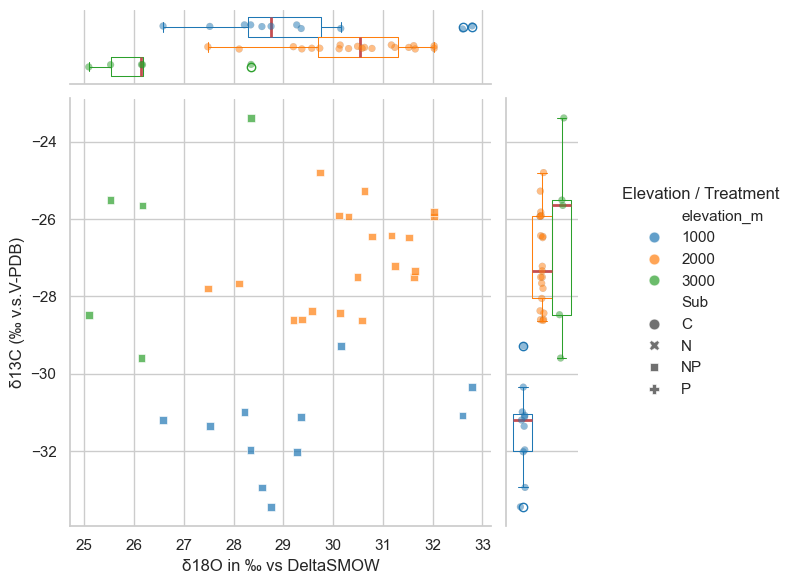

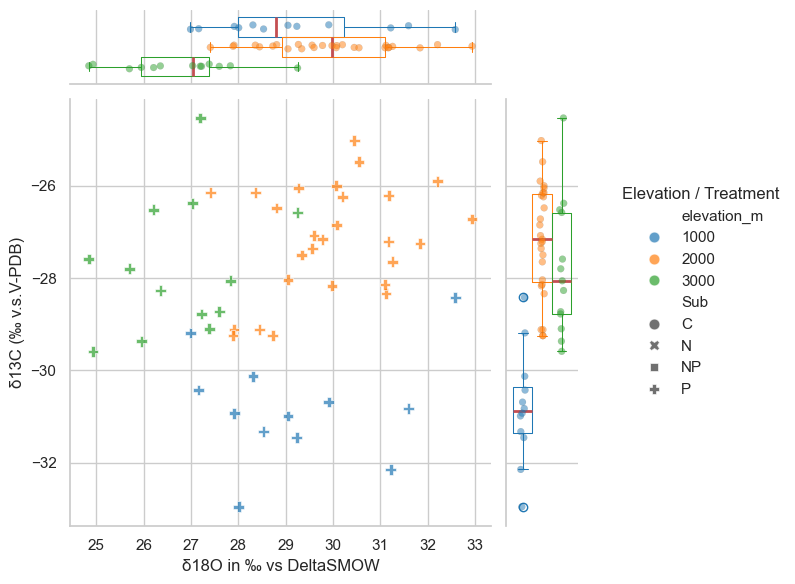

In [21]:
data_C = data[data["Sub"] == "C"]
data_P = data[data["Sub"] == "P"]
data_NP = data[data["Sub"] == "NP"]
data_N = data[data["Sub"] == "N"]

def plot_d12_d18(data):
 g = sns.JointGrid(data=data, y=named13C_cellulose, x= name18O, hue="elevation_m", palette="tab10")
 g.plot_joint(sns.scatterplot, data=data,          # 👈 CLAVE
    style="Sub",        # o "name" si ese es tu factor
    s=60,
    alpha=0.7)
 g.plot_marginals(sns.stripplot, hue="Sub", linewidth=0.1,dodge=True,alpha=.5)
 g.plot_marginals(sns.boxplot, hue="Sub",fill=False,linewidth=.75,
                 medianprops={"color": "r", "linewidth": 2})
 g.ax_joint.legend_.remove()
 # ── LEYENDA FUERA ───────────────────────────────
 handles, labels = g.ax_joint.get_legend_handles_labels()

 # crear leyenda externa
 g.fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    title="Elevation / Treatment"
 )

 return g

plot_d12_d18(data_C)
plot_d12_d18(data_N)
plot_d12_d18(data_NP)
plot_d12_d18(data_P)


### No usar pero crea los codigos en relacion delta 13/ d18O

especies = ["Pouteria torta",
  "Alchornea lojaensis",
  "Weinmania  loxensis",
  "Clarisia  racemosa",
  "Myrcia sp nov",
  "Hedyosmun  purpurascens"] #creamos vector especies 
for especie in especies:
    df_name = "df_"+especie
    df_name = data[data["name"]== especie]
    g = sns.JointGrid(data=df_name, x=vp4, y=vp3, hue="Sub", palette="tab10",height=4)
    g.plot_joint(sns.scatterplot, legend=False)
    g.plot_marginals(sns.stripplot, hue="Sub", linewidth=0.1,dodge=True,alpha=.5, legend=False)
    g.plot_marginals(sns.boxplot, hue="Sub",fill=False,linewidth=.75,
                 medianprops={"color": "r", "linewidth": 2},legend=False)
    
    g.ax_joint.set_xlim(22, 36)
    g.ax_joint.set_ylim(-22, -36 )
    g.ax_marg_x.set_xlim(25 ,36)
    #g.ax_marg_y.set_ylim(-22, -35)
    mean_x= df_name[df_name["Sub"]=="C"][vp4].mean() 
    mean_y= df_name[df_name["Sub"]=="C"][vp3].mean() 
    g.refline(x=mean_x, y=mean_y) #means of the control
    g.fig.suptitle(especie, y=1.02, style="italic") #

    

| **Pattern**                          | **Interpretation**                                                                          |
| ------------------------------------ | ------------------------------------------------------------------------------------------- |
| Both δ¹³C and δ¹⁸O increase          | Likely due to **reduced stomatal conductance** → both iWUE and leaf water δ¹⁸O increase.    |
| δ¹³C increases but δ¹⁸O does not     | Possibly due to **increased photosynthesis**, not stomatal closure.                         |
| δ¹³C does not increase but δ¹⁸O does | Could indicate **stomatal closure**, but photosynthesis also dropped → no iWUE gain.        |
| No correlation                       | Suggests other processes dominate (e.g., environmental noise, post-photosynthetic effects). |
